In [1]:
import os
import re
import pickle
import subprocess
import pandas as pd
from glob import glob
import numpy as np
from scipy.stats import mannwhitneyu
import scipy
from scipy.stats import spearmanr, pearsonr
import qtl.plot
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import copy
plt.rcParams.update({'font.family':'Helvetica', 
                     'svg.fonttype':'none',
                     'pdf.fonttype':42, 
                     'font.size':12})


def peak_dist_to_variant(row, 
                         peak_col='phenotype_id', 
                         variant_col='variant_id'):
    region = row[peak_col]
    region_start, region_end = region.split(":")[1].split("-")
    region_start = int(region_start)
    region_end = int(region_end)
    snp_pos = int(row[variant_col].split(":")[1])

    if snp_pos < region_start:
        dist = (region_start - snp_pos)
    elif snp_pos > region_end:
        dist = (snp_pos - region_end)
    else:
        dist = 0
    return dist



def scatter(x, y, c=None, kind='scatter', cmap=None, colorbar=True, corr_loc='lower right', show_pval=False,
            lowess=False, lowess_frac=0.3, gridsize=50, extent=None, xscale='linear', yscale='linear', margins=0,
            clip_on=False, entity='Cells', ax=None, cax=None, dr=1, **kwargs):
    """Wrapper for scatter plot, with option to plot density"""

    if kind == 'scatter':
        if ax is None:
            ax = qtl.plot.setup_figure(2,2)
            ax.margins(margins)
            qtl.plot.format_plot(ax, x_offset=6, y_offset=6)
        if 'ec' not in kwargs:
            kwargs.update({'ec':'none'})
        ax.set_xscale(xscale)
        ax.set_yscale(yscale)
        ax.scatter(x, y, c=c, clip_on=clip_on, **kwargs)

    elif kind == 'density':
        if ax is None:
            if colorbar:
                xspace = [0.75, dr]
            else:
                xspace = [0.75, 0.25]
            ax, cax = qtl.plot.setup_figure(2, 2, xspace=xspace, colorbar=colorbar)
            ax.margins(margins)
            qtl.plot.format_plot(ax, x_offset=6, y_offset=6)
        if cmap is None:
            cmap = copy.copy(plt.cm.RdYlBu_r)
            cmap.set_bad('w', 1.)

        h = ax.hexbin(x, y, gridsize=gridsize, extent=extent, bins='log', mincnt=1, linewidths=0.1,
                      xscale=xscale, yscale=yscale, cmap=cmap, clip_on=clip_on, **kwargs)
        if colorbar and cax is not None:
            bbox = cax.get_window_extent()
            if bbox.height >= bbox.width:
                plt.colorbar(h, cax=cax, ticks=ticker.LogLocator(numticks=5))
                cax.set_ylabel('log$\mathregular{_{10}}$('+entity+')', fontsize=11)
            else:
                plt.colorbar(h, cax=cax, ticks=ticker.LogLocator(numticks=5), orientation='horizontal')
                cax.xaxis.set_label_position('top')
                # cax.xaxis.tick_top()
                cax.set_xlabel('log$\mathregular{_{10}}$('+entity+')', fontsize=11)

    if lowess:
        lw = sm.nonparametric.lowess(y, x, lowess_frac)
        ax.plot(lw[:, 0], lw[:, 1], '-', color='tab:red', lw=2)

    if corr_loc is not None:
        rho, pval = scipy.stats.spearmanr(x, y, nan_policy='omit')
        r, pval = scipy.stats.pearsonr(x, y) 
        t = fr"$\rho$ = {rho:.2f}"+ f"\nR = {r:.2f}"
        if show_pval:
            t += f"\nP = {pval:.2g}"
        if corr_loc == 'lower right':
            ax.text(1, 0, t, fontsize=11, ha='right', va='bottom', transform=ax.transAxes)
        elif corr_loc == 'upper right':
            ax.text(1, 0.98, t, fontsize=11, ha='right', va='top', transform=ax.transAxes)
        elif corr_loc == 'upper left':
            ax.text(0.02, 0.98, t, fontsize=11, ha='left', va='top', transform=ax.transAxes)
        elif corr_loc == 'lower left':
            ax.text(0.02, 0, t, fontsize=11, ha='left', va='bottom', transform=ax.transAxes)

    if isinstance(x, pd.Series):
        ax.set_xlabel(x.name, fontsize=12)
    if isinstance(y, pd.Series):
        ax.set_ylabel(y.name, fontsize=12)

    if kind == 'density' and colorbar:
        return ax, cax, h
    else:
        return ax

<>:76: SyntaxWarning: invalid escape sequence '\m'
<>:81: SyntaxWarning: invalid escape sequence '\m'
<>:76: SyntaxWarning: invalid escape sequence '\m'
<>:81: SyntaxWarning: invalid escape sequence '\m'
/scratch/158277.1.whole/ipykernel_23290/434714813.py:76: SyntaxWarning: invalid escape sequence '\m'
  cax.set_ylabel('log$\mathregular{_{10}}$('+entity+')', fontsize=11)
/scratch/158277.1.whole/ipykernel_23290/434714813.py:81: SyntaxWarning: invalid escape sequence '\m'
  cax.set_xlabel('log$\mathregular{_{10}}$('+entity+')', fontsize=11)


In [2]:
# source data files
cell_type_counts_fn = "data/combined_obs_cell_type_counts.tsv"
score_fn = 'data/TenK10K.caQTL.Final1Mb.susie_finemapped_results_w_ChromBPNetScores.csv.gz'
out_figure_dir = 'figures/'
if not os.path.exists(out_figure_dir): os.makedirs(out_figure_dir)

In [3]:
# load data
cell_type_counts = pd.read_csv(cell_type_counts_fn, sep='\t')
cell_type_counts['label'] = cell_type_counts['predicted.id'] + ' (N=' + cell_type_counts['count'].astype(str) + ')'
cell_type_counts = cell_type_counts.set_index("predicted.id")
df = pd.read_csv(score_fn)

# Observed effect size vs. ChromBPNet score, straitified by distance

In [4]:
df['abs_log_counts_diff'] = df['log_counts_diff'].abs()
df['abs_probs_jsd_diff'] = df['probs_jsd_diff'].abs()
df['abs_slope'] = df['slope'].abs()

In [5]:
records = []
for d in [0, 500, 1000, 5000, 100000, 1000000]:
    for cell_type, grp in df[df['is_snp']].groupby('celltype'):
        for min_pip in [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
            t = grp[(grp['dist_to_variant'] <= d) & (grp['PIP'] >= min_pip)]
            if len(t) > 2:
                for col1 in ['slope']:
                #for col1 in ['slope', 'abs_slope']:
                    for col2 in ['log_counts_diff']: #'probs_jsd_diff', 
                                 #'abs_log_counts_diff', 'abs_probs_jsd_diff',
                                 #'log_probs_diff_abs_sum']:
                        record = {
                            "metric1": col1,
                            "metric2": col2,
                            "spearmanr": spearmanr(t[col1], t[col2])[0],
                            "pearsonr": pearsonr(t[col1], t[col2])[0],
                            "N": len(t),
                            "max_dist_to_variant": d,
                            "cell type": cell_type,
                            'min_pip': min_pip
                        }
                        records.append(record)
perf = pd.DataFrame(records).sort_values("spearmanr", ascending=False)
perf['cell type count'] = perf.apply(lambda x: cell_type_counts.loc[x['cell type'], 'count'], axis=1)
perf['label'] = perf['cell type'] + ' (#cells=' + perf['cell type count'].astype(str) + ')'
perf.to_csv(os.path.join(out_figure_dir, 'caQTL_slop_vs_ChromBPNet_scores_finemapped_variants.csv'), index=False)

In [6]:
perf.head()

,metric1,metric2,spearmanr,pearsonr,N,max_dist_to_variant,cell type,min_pip,cell type count,label
195,slope,log_counts_diff,1.0,0.998006,3,0,NK_Proliferating,0.90,2592,NK_Proliferating (#cells=2592)
194,slope,log_counts_diff,1.0,0.996706,4,0,NK_Proliferating,0.80,2592,NK_Proliferating (#cells=2592)
192,slope,log_counts_diff,1.0,0.996706,4,0,NK_Proliferating,0.60,2592,NK_Proliferating (#cells=2592)
196,slope,log_counts_diff,1.0,0.998006,3,0,NK_Proliferating,0.95,2592,NK_Proliferating (#cells=2592)
193,slope,log_counts_diff,1.0,0.996706,4,0,NK_Proliferating,0.70,2592,NK_Proliferating (#cells=2592)


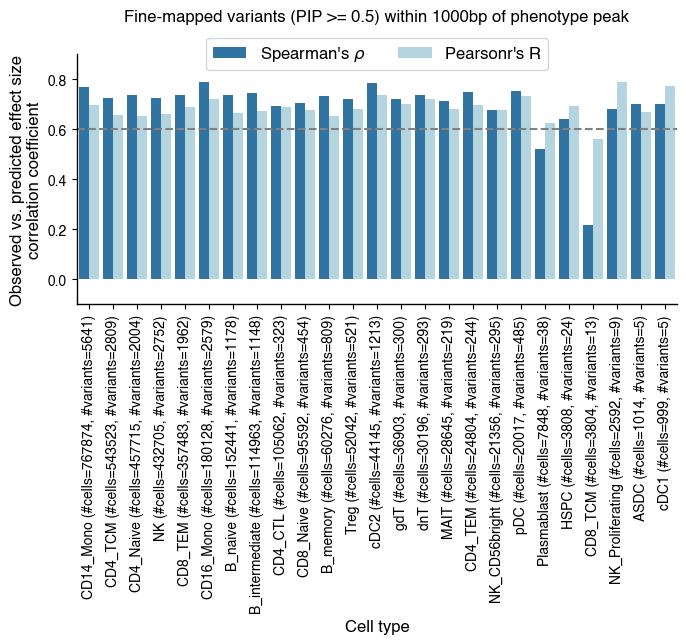

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


In [7]:
#for max_dist in [0,1000, 5000]:
for max_dist in [1000]:
    t = perf[(perf['metric1'] == 'slope') \
            & (perf['metric2'] == 'log_counts_diff') \
            & (perf['max_dist_to_variant'] == max_dist)\
            & (perf['min_pip'] == 0.5)]
    val_cell_types = cell_type_counts[cell_type_counts.index.isin(t['cell type'].unique())].index
    t = t.set_index('cell type').loc[val_cell_types].reset_index()
    t = t.rename(columns={'spearmanr': 'corr_spearmanr', 'pearsonr': 'corr_pearsonr', 'predicted.id': 'cell type'})
    t = pd.wide_to_long(t, stubnames=['corr'],  
                    i=['metric1', 'metric2', 'N',
                       'max_dist_to_variant', 
                       'cell type', 
                       'cell type count',
                       'label'],
                    j='corr_method',
                    sep='_',
                    suffix='.+').reset_index()
    t['label'] = t.apply(lambda x: x['label'].replace(')', f", #variants={x['N']})"),axis=1)

    ax = qtl.plot.setup_figure(6, 2.5)
    qtl.plot.format_plot(ax)
    # sns.barplot(x='label', y=metric, 
    #                data=t, color='grey')
    sns.barplot(x='label', y='corr',  hue='corr_method',
                data=t, 
                palette=['tab:blue', 'lightblue'])
    ax.set_xlabel('Cell type')
    ax.set_ylabel('Observed vs. predicted effect size\ncorrelation coefficient')
    #ax.bar_label(ax.containers[0], fmt='%.1f', padding=0, fontsize=8)
    #ax.bar_label(ax.containers[1], fmt='%.1f', padding=0, fontsize=8)
    if max_dist == 0:
        ax.set_title('Fine-mapped variants (PIP >= 0.5) within phenotype peak',fontsize=12, y=1.1)
    else:
        ax.set_title(f'Fine-mapped variants (PIP >= 0.5) within {max_dist}bp of phenotype peak',fontsize=12, y=1.1)
    handles, labels = plt.gca().get_legend_handles_labels()
    ax.legend(handles, ["Spearman's " + r"$\rho$", "Pearsonr's R"], 
              loc='upper center', ncols=2, bbox_to_anchor=(0.5, 1.1))
    
    ax.axhline(0.6, ls='--', color='grey')
    
    ax.set_ylim(-0.1, 0.9)
    plt.xticks(rotation=90)
    plt.show()
    
    ax.get_figure().savefig(os.path.join(out_figure_dir, f"TenK10K_chromBPNet_pred_vs_observed_straitified_by_cell_type_max_dist_{max_dist}.pdf"),
                    dpi=300, bbox_inches='tight')

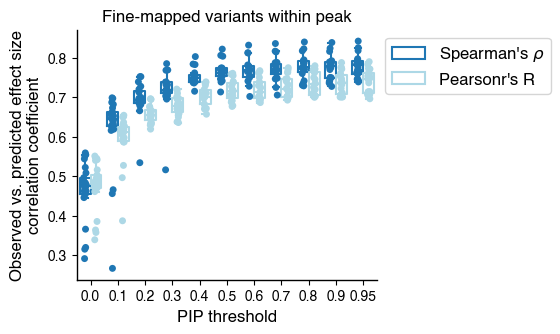

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


In [8]:
t = perf[(perf['metric1'] == 'slope') \
        & (perf['metric2'] == 'log_counts_diff') \
        & (perf['max_dist_to_variant'] == 0) \
        & (perf['N'] >= 50)]
t = t.rename(columns={'spearmanr': 'corr_spearmanr', 
                      'pearsonr': 'corr_pearsonr'})
t = pd.wide_to_long(t, stubnames=['corr'],  
                i=['metric1', 'metric2', 'N',
                   'max_dist_to_variant', 
                   'cell type',
                   'cell type count',
                   'label'],
                j='corr_method',
                sep='_',
                suffix='.+').reset_index()


ax = qtl.plot.setup_figure(3, 2.5)
qtl.plot.format_plot(ax)
sns.boxplot(x='min_pip', y='corr',  hue='corr_method',
            data=t, fill=False, fliersize=0, 
            palette=['tab:blue', 'lightblue'])
sns.stripplot(x='min_pip', y='corr', hue='corr_method', 
               data=t, dodge=True, palette=['tab:blue', 'lightblue'])
ax.set_xlabel('PIP threshold')
ax.set_ylabel('Observed vs. predicted effect size\ncorrelation coefficient')
ax.set_title('Fine-mapped variants within peak', fontsize=12)
#ax.set_xticklabels( [0, 500, 1000, 5000, '1e5', '1e6'])

handles, labels = plt.gca().get_legend_handles_labels()
ax.legend(handles[:2], ["Spearman's " + r"$\rho$", "Pearsonr's R"], bbox_to_anchor=(1, 1))
plt.show()

ax.get_figure().savefig(os.path.join(out_figure_dir, f"TenK10K_chromBPNet_pred_vs_observed_scatterplot_variant_within_the_peak.pdf"),
                        dpi=300, bbox_inches='tight')

ASDC, HSPC, cDC1, NK_Proliferating, Plasmablast, CD8_TCM, CD4_Proliferating are omitted due to sample size <= 50.


/scratch/158277.1.whole/ipykernel_23290/1523938183.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels( [0, 500, 1000, 5000, '1e5', '1e6'])


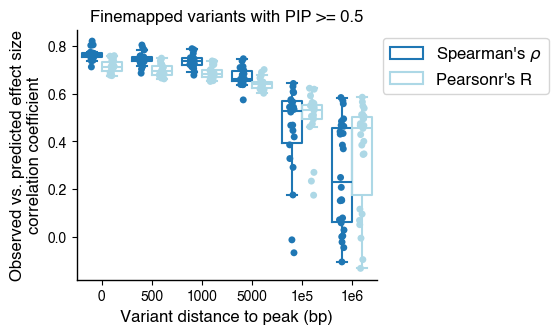

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


In [9]:
#for min_pip in [0, 0.5, 0.6, 0.7, 0.8, 0.9]:
for min_pip in [0.5]:
    t = perf[(perf['metric1'] == 'slope') \
            & (perf['metric2'] == 'log_counts_diff') \
            & (perf['min_pip'] == min_pip)]
    cell_types_w_too_few_datapoints = t[t['N'] < 50]['cell type'].unique()
    print(f"{', '.join(cell_types_w_too_few_datapoints)} are omitted due to sample size <= 50.")
    t = t[t['N'] >= 50]
    t = t.rename(columns={'spearmanr': 'corr_spearmanr', 'pearsonr': 'corr_pearsonr'})
    t = pd.wide_to_long(t, stubnames=['corr'],  
                    i=['metric1', 'metric2', 'N',
                       'max_dist_to_variant', 
                       'cell type',
                       'cell type count',
                       'label'],
                    j='corr_method',
                    sep='_',
                    suffix='.+').reset_index()
    
    
    ax = qtl.plot.setup_figure(3, 2.5)
    qtl.plot.format_plot(ax)
    sns.boxplot(x='max_dist_to_variant', y='corr',  hue='corr_method',
                data=t, fill=False, fliersize=0, 
                palette=['tab:blue', 'lightblue'])
    sns.stripplot(x='max_dist_to_variant', y='corr', hue='corr_method', 
                   data=t, dodge=True, palette=['tab:blue', 'lightblue'])
    ax.set_xlabel('Variant distance to peak (bp)')
    ax.set_ylabel('Observed vs. predicted effect size\ncorrelation coefficient')
    ax.set_xticklabels( [0, 500, 1000, 5000, '1e5', '1e6'])
    ax.set_title(f'Finemapped variants with PIP >= {min_pip:.1f}', fontsize=12)
    handles, labels = plt.gca().get_legend_handles_labels()
    ax.legend(handles[:2], ["Spearman's " + r"$\rho$", "Pearsonr's R"], bbox_to_anchor=(1.6, 1))
    plt.show()
    
    ax.get_figure().savefig(os.path.join(out_figure_dir, f"TenK10K_chromBPNet_finemapped_SNP_minPIP{min_pip:1f}_pred_vs_observed_straitified_by_variant_distance_to_peak.pdf"),
                            dpi=300, bbox_inches='tight')

NK_Proliferating, Plasmablast, CD8_TCM, cDC1, ASDC, HSPC, CD4_Proliferating are omitted due to sample size <= 50.


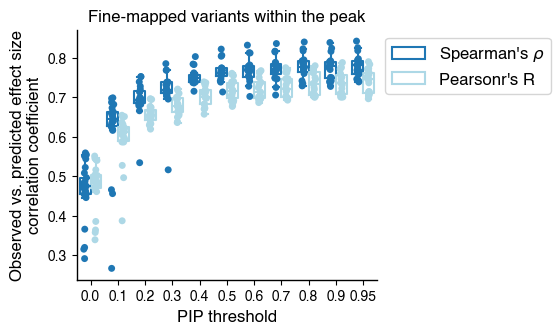

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


(22582, 25) (11105,)


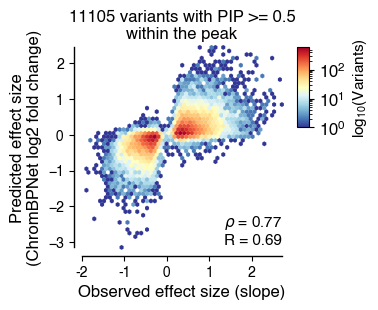

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


NK_Proliferating, cDC1, Plasmablast, ASDC, HSPC, CD8_TCM, CD4_Proliferating are omitted due to sample size <= 50.


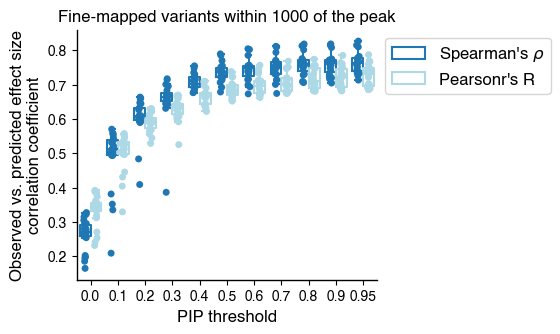

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


(25323, 25) (12750,)


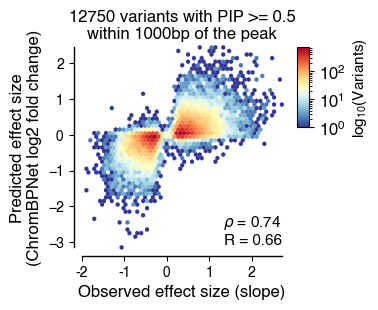

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


NK_Proliferating, cDC1, Plasmablast, ASDC, HSPC, CD8_TCM, CD4_Proliferating are omitted due to sample size <= 50.


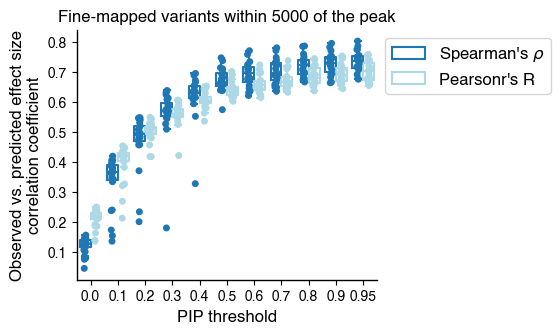

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


(30699, 25) (15783,)


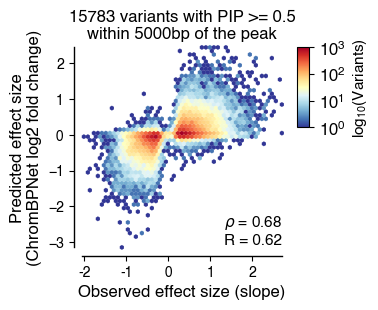

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


NK_Proliferating, HSPC, CD4_Proliferating, cDC1, ASDC, CD8_TCM are omitted due to sample size <= 50.


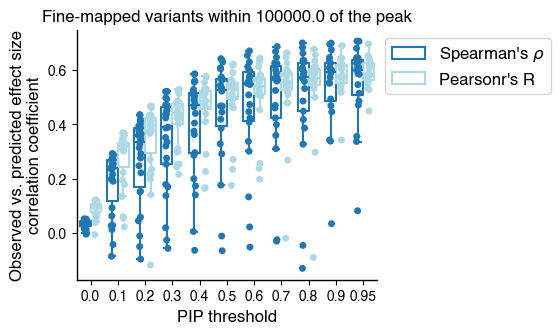

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


(46581, 25) (23974,)


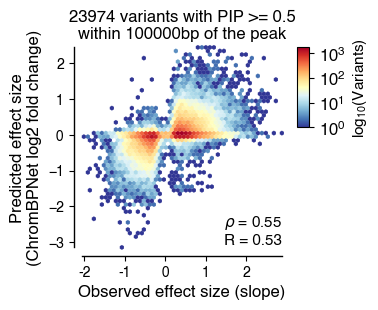

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


 are omitted due to sample size <= 50.


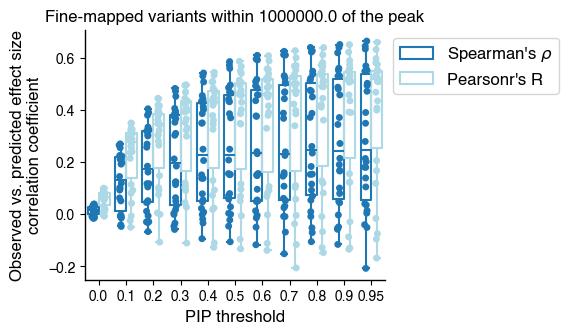

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


(66788, 25) (40220,)


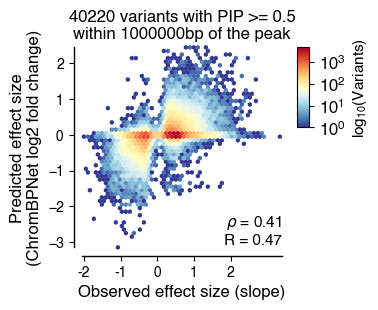

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


In [10]:
for max_dist in [0, 1000, 5000, 1e5, 1e6]:
    t = perf[(perf['metric1'] == 'slope') \
            & (perf['metric2'] == 'log_counts_diff') \
            & (perf['max_dist_to_variant'] == max_dist)]
    cell_types_w_too_few_datapoints = t[t['N'] < 50]['cell type'].unique()
    print(f"{', '.join(cell_types_w_too_few_datapoints)} are omitted due to sample size <= 50.")
    t = t[t['N'] >= 50]
    t = t.rename(columns={'spearmanr': 'corr_spearmanr', 
                          'pearsonr': 'corr_pearsonr'})
    t = pd.wide_to_long(t, stubnames=['corr'],  
                    i=['metric1', 'metric2', 'N',
                       'max_dist_to_variant', 
                       'cell type',
                       'cell type count',
                       'label'],
                    j='corr_method',
                    sep='_',
                    suffix='.+').reset_index()

    ax = qtl.plot.setup_figure(3, 2.5)
    qtl.plot.format_plot(ax)
    sns.boxplot(x='min_pip', y='corr',  hue='corr_method',
                data=t, fill=False, fliersize=0, 
                palette=['tab:blue', 'lightblue'])
    sns.stripplot(x='min_pip', y='corr', hue='corr_method', 
                   data=t, dodge=True, palette=['tab:blue', 'lightblue'])
    ax.set_xlabel('PIP threshold')
    ax.set_ylabel('Observed vs. predicted effect size\ncorrelation coefficient')
    if max_dist > 0:
        ax.set_title(f'Fine-mapped variants within {max_dist} of the peak', fontsize=12)
    else:
        ax.set_title(f'Fine-mapped variants within the peak', fontsize=12)
    
    handles, labels = plt.gca().get_legend_handles_labels()
    ax.legend(handles[:2], ["Spearman's " + r"$\rho$", "Pearsonr's R"], bbox_to_anchor=(1, 1))
    plt.show()
    
    ax.get_figure().savefig(os.path.join(out_figure_dir, f"TenK10K_chromBPNet_pred_vs_observed_scatterplot_variant_within_{max_dist}bp_of_the_peak.pdf"),
                            dpi=300, bbox_inches='tight')

    for min_pip in [0.5]:
        t = df[(df['dist_to_variant'] <= max_dist) & (df['PIP'] >= min_pip) & (df['is_snp'])]
        print(t.shape, t['SNP'].unique().shape)
        
        ax, cax, h = scatter(t['slope'], t['log_counts_diff'],
                             kind='density', entity='Variants')
        ax.set_xlabel(f'Observed effect size (slope)')
        ax.set_ylabel(f'Predicted effect size\n(ChromBPNet log2 fold change)')
        if max_dist > 0:
            ax.set_title(f"{len(t['SNP'].unique())} variants with PIP >= {min_pip:.1f}\nwithin {max_dist:.0f}bp of the peak", fontsize=12)
        else:
            ax.set_title(f"{len(t['SNP'].unique())} variants with PIP >= {min_pip:.1f}\nwithin the peak", fontsize=12)
        ax.set_xticks([-2, -1, 0, 1, 2],[-2, -1, 0, 1, 2])
        plt.show()
        
        ax.get_figure().savefig(os.path.join(out_figure_dir, f"TenK10K_chromBPNet_finemapped_variants_minPIP{min_pip:.1f}_pred_vs_observed_scatterplot_variant_within_{max_dist}bp_of_the_peak.pdf"),
                                dpi=300, bbox_inches='tight')

# Compare top variants and fine-mapped variants results

In [11]:
top_df = pd.read_csv('data/caQTL_slop_vs_ChromBPNet_scores_top_variants.csv')
top_df = top_df[top_df['min_af'] == 0]
top_df.drop('min_af', axis=1, inplace=True)
top_df.head(2)

,metric1,metric2,spearmanr,pearsonr,N,max_dist_to_variant,cell type,cell type count,label
3,slope,log_counts_diff,0.769189,0.696545,6629,0,CD16_Mono,180128,CD16_Mono (#cells=180128)
4,slope,log_counts_diff,0.767162,0.687166,1491,0,pDC,20017,pDC (#cells=20017)


In [12]:
finemapped_df = pd.read_csv('figures/caQTL_slop_vs_ChromBPNet_scores_finemapped_variants.csv')

In [13]:
finemapped_df = finemapped_df[finemapped_df['min_pip'] >= 0.5]
finemapped_df.drop('min_pip', axis=1, inplace=True)
finemapped_df.head(2)

,metric1,metric2,spearmanr,pearsonr,N,max_dist_to_variant,cell type,cell type count,label
0,slope,log_counts_diff,1.0,0.998006,3,0,NK_Proliferating,2592,NK_Proliferating (#cells=2592)
1,slope,log_counts_diff,1.0,0.996706,4,0,NK_Proliferating,2592,NK_Proliferating (#cells=2592)


In [14]:
top_df['variant type'] = 'Top variants'
finemapped_df['variant type'] = 'Finemapped'
tperf = pd.concat([top_df, finemapped_df])

/scratch/158277.1.whole/ipykernel_23290/2798626931.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels( [0, 500, 1000, 5000, '1e5', '1e6'])


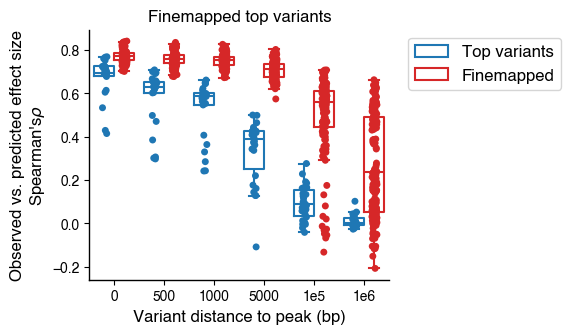

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


In [15]:
t = tperf[(tperf['metric1'] == 'slope') \
        & (tperf['metric2'] == 'log_counts_diff') \
        & (tperf['N'] >= 50)]
t = t.rename(columns={'spearmanr': 'corr_spearmanr', 
                      'pearsonr': 'corr_pearsonr'})

ax = qtl.plot.setup_figure(3, 2.5)
qtl.plot.format_plot(ax)
sns.boxplot(x='max_dist_to_variant', y='corr_spearmanr',  hue='variant type',
            data=t, fill=False, fliersize=0, 
            palette=['tab:blue', 'tab:red'])
sns.stripplot(x='max_dist_to_variant', y='corr_spearmanr', hue='variant type', 
               data=t, dodge=True, palette=['tab:blue', 'tab:red'])
ax.set_xlabel('Variant distance to peak (bp)')
ax.set_ylabel("Observed vs. predicted effect size\nSpearman's" + r"$\rho$")
ax.set_xticklabels( [0, 500, 1000, 5000, '1e5', '1e6'])
ax.set_title(f'Finemapped top variants', fontsize=12)
handles, labels = plt.gca().get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], bbox_to_anchor=(1.6, 1))
plt.show()

ax.get_figure().savefig(os.path.join(out_figure_dir, f"TenK10K_chromBPNet_finemapped_vs_top_variants_pred_vs_observed_straitified_by_variant_distance_to_peak.pdf"),
                        dpi=300, bbox_inches='tight')